In [44]:
import pandas as pd
import numpy as np
import random
import os
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBClassifier, XGBRegressor

import warnings
warnings.filterwarnings("ignore")

In [45]:
# ----------------------------
# MASTER CONFIG
# ----------------------------

crop_types = [
    'wheat', 'rice', 'maize', 'sugarcane', 'cotton',
    'potato', 'tomato', 'onion', 'soybean', 'mustard',
    'barley', 'gram', 'pea', 'groundnut', 'sunflower',
    'millet', 'sorghum', 'cabbage', 'cauliflower', 'chilli',
    'brinjal', 'okra', 'banana', 'papaya', 'watermelon'
]

soil_types = ['sandy', 'loamy', 'clay', 'silty', 'black', 'red']
crop_stages = ['germination', 'vegetative', 'flowering', 'fruiting', 'maturity']
drainage_conditions = ['poor', 'moderate', 'good']
irrigation_methods = ['drip', 'sprinkler', 'flood']
mulching_options = ['yes', 'no']
weather_conditions = ['sunny', 'cloudy', 'humid', 'dry', 'rainy']
waterlogging_levels = ['low', 'medium', 'high']
zone_positions = ['corner', 'edge', 'center']

In [46]:
# ----------------------------
# DOMAIN KNOWLEDGE DICTIONARIES
# ----------------------------

soil_retention = {
    'sandy': 0.30,
    'loamy': 0.70,
    'clay': 0.85,
    'silty': 0.65,
    'black': 0.80,
    'red': 0.50
}

drainage_factor = {
    'poor': 0.9,
    'moderate': 0.5,
    'good': 0.2
}

crop_stage_water_need = {
    'germination': 0.6,
    'vegetative': 0.8,
    'flowering': 1.0,
    'fruiting': 0.95,
    'maturity': 0.5
}

crop_stage_nutrient_need = {
    'germination': 0.4,
    'vegetative': 0.8,
    'flowering': 1.0,
    'fruiting': 0.9,
    'maturity': 0.5
}

crop_water_sensitivity = {
    'wheat': 0.7, 'rice': 1.0, 'maize': 0.8, 'sugarcane': 0.95, 'cotton': 0.75,
    'potato': 0.85, 'tomato': 0.9, 'onion': 0.8, 'soybean': 0.7, 'mustard': 0.6,
    'barley': 0.55, 'gram': 0.5, 'pea': 0.65, 'groundnut': 0.7, 'sunflower': 0.65,
    'millet': 0.45, 'sorghum': 0.5, 'cabbage': 0.85, 'cauliflower': 0.85, 'chilli': 0.8,
    'brinjal': 0.82, 'okra': 0.75, 'banana': 0.95, 'papaya': 0.9, 'watermelon': 0.88
}

crop_disease_sensitivity = {
    'wheat': 0.45, 'rice': 0.7, 'maize': 0.5, 'sugarcane': 0.55, 'cotton': 0.65,
    'potato': 0.8, 'tomato': 0.9, 'onion': 0.75, 'soybean': 0.55, 'mustard': 0.5,
    'barley': 0.4, 'gram': 0.45, 'pea': 0.55, 'groundnut': 0.6, 'sunflower': 0.55,
    'millet': 0.35, 'sorghum': 0.35, 'cabbage': 0.8, 'cauliflower': 0.8, 'chilli': 0.78,
    'brinjal': 0.82, 'okra': 0.68, 'banana': 0.72, 'papaya': 0.76, 'watermelon': 0.74
}

irrigation_efficiency = {
    'drip': 0.90,
    'sprinkler': 0.75,
    'flood': 0.55
}

In [47]:
# ----------------------------
# HELPER FUNCTIONS
# ----------------------------

def determine_crop_stage(age):
    if age <= 15:
        return 'germination'
    elif age <= 45:
        return 'vegetative'
    elif age <= 75:
        return 'flowering'
    elif age <= 110:
        return 'fruiting'
    else:
        return 'maturity'

def calculate_ndvi(soil_moisture, crop_stage, disease_risk_score, fertilizer_deficiency_score):
    base = 0.25 + (soil_moisture / 100) * 0.5
    
    stage_bonus = {
        'germination': 0.05,
        'vegetative': 0.18,
        'flowering': 0.20,
        'fruiting': 0.16,
        'maturity': 0.08
    }[crop_stage]
    
    ndvi = base + stage_bonus - (disease_risk_score * 0.15) - (fertilizer_deficiency_score * 0.12)
    ndvi += np.random.normal(0, 0.03)
    return round(np.clip(ndvi, 0.10, 0.92), 3)

def calculate_disease_risk(temperature, humidity, crop, stage, rainfall_last_24h, drainage):
    score = 0
    
    if humidity > 75:
        score += 0.25
    elif humidity > 60:
        score += 0.12
        
    if 22 <= temperature <= 34:
        score += 0.15
        
    if rainfall_last_24h > 10:
        score += 0.18
        
    if drainage == 'poor':
        score += 0.15
        
    score += crop_disease_sensitivity[crop] * 0.2
    score += crop_stage_water_need[stage] * 0.1
    
    score += np.random.normal(0, 0.04)
    return round(float(np.clip(score, 0.01, 0.99)), 3)

def calculate_fertilizer_deficiency(crop_stage, soil_type, crop_age, ndvi_proxy):
    score = 0.15
    
    score += crop_stage_nutrient_need[crop_stage] * 0.35
    
    if soil_type == 'sandy':
        score += 0.18
    elif soil_type == 'red':
        score += 0.12
        
    if crop_age > 45:
        score += 0.10
        
    if ndvi_proxy < 0.35:
        score += 0.15
        
    score += np.random.normal(0, 0.04)
    return round(float(np.clip(score, 0.01, 0.99)), 3)

def calculate_irrigation_score(soil_moisture, temperature, humidity, crop_stage, rainfall_forecast, et):
    score = 0
    
    if soil_moisture < 20:
        score += 0.45
    elif soil_moisture < 30:
        score += 0.28
        
    if temperature > 34:
        score += 0.15
        
    if humidity < 40:
        score += 0.10
        
    score += crop_stage_water_need[crop_stage] * 0.20
    
    if rainfall_forecast > 10:
        score -= 0.20
        
    if et > 5:
        score += 0.10
        
    score += np.random.normal(0, 0.03)
    return round(float(np.clip(score, 0.01, 0.99)), 3)

def calculate_waterlogging_risk(soil_moisture, rainfall_last_24h, drainage, soil_type):
    score = 0
    
    if soil_moisture > 75:
        score += 0.45
    elif soil_moisture > 60:
        score += 0.25
        
    if rainfall_last_24h > 15:
        score += 0.20
        
    if drainage == 'poor':
        score += 0.20
        
    if soil_type in ['clay', 'black']:
        score += 0.15
        
    score += np.random.normal(0, 0.03)
    score = np.clip(score, 0.01, 0.99)
    
    if score > 0.70:
        return 'high', round(score, 3)
    elif score > 0.40:
        return 'medium', round(score, 3)
    else:
        return 'low', round(score, 3)

def get_zone_health_score(soil_moisture, ndvi_score, disease_risk_score, fertilizer_deficiency_score, irrigation_score, waterlogging_score):
    score = 100
    
    score -= max(0, (25 - soil_moisture)) * 1.2
    score += ndvi_score * 25
    score -= disease_risk_score * 28
    score -= fertilizer_deficiency_score * 20
    score -= irrigation_score * 12
    score -= waterlogging_score * 18
    
    score += np.random.normal(0, 3)
    return round(float(np.clip(score, 5, 98)), 2)

def assign_zone_status(soil_moisture, ndvi_score, disease_risk_score, fertilizer_deficiency_score, waterlogging_risk, irrigation_score, zone_health_score):
    # Priority-based classification
    
    if waterlogging_risk == 'high' or (soil_moisture > 78 and ndvi_score < 0.45):
        return 'Overwatered'
    
    if fertilizer_deficiency_score > 0.72 and ndvi_score < 0.42:
        return 'Nutrient Deficient'
    
    if disease_risk_score > 0.72 or zone_health_score < 35:
        return 'Risky'
    
    if irrigation_score > 0.65 and soil_moisture < 25 and ndvi_score < 0.45:
        return 'Dry'
    
    return 'Healthy'

def generate_recommendation(zone_status):
    recommendations = {
        'Dry': 'Irrigate this zone soon. Monitor moisture and avoid delay.',
        'Healthy': 'Zone is stable. Continue regular monitoring only.',
        'Risky': 'Inspect crop for disease or stress symptoms. Take preventive action.',
        'Overwatered': 'Avoid irrigation. Improve drainage and monitor root health.',
        'Nutrient Deficient': 'Apply balanced fertilizer or nitrogen-rich nutrients.'
    }
    return recommendations[zone_status]

In [48]:
def generate_zone_row(field_id, zone_row, zone_col, total_rows=5, total_cols=5):
    crop = random.choice(crop_types)
    crop_age_days = random.randint(1, 140)
    crop_stage = determine_crop_stage(crop_age_days)
    soil_type = random.choice(soil_types)
    drainage_condition = random.choice(drainage_conditions)
    irrigation_method = random.choice(irrigation_methods)
    mulching = random.choice(mulching_options)
    weather_condition = random.choice(weather_conditions)

    # Zone position
    if zone_row in [0, total_rows-1] and zone_col in [0, total_cols-1]:
        zone_position = 'corner'
    elif zone_row in [0, total_rows-1] or zone_col in [0, total_cols-1]:
        zone_position = 'edge'
    else:
        zone_position = 'center'

    # Environmental values
    soil_moisture = round(np.random.uniform(8, 88), 2)
    temperature_c = round(np.random.uniform(18, 42), 2)
    humidity_percent = round(np.random.uniform(25, 95), 2)
    rainfall_last_24h_mm = round(np.random.uniform(0, 30), 2)
    rain_probability_next_24h = random.randint(0, 100)
    soil_temperature_c = round(np.random.uniform(15, 38), 2)
    wind_speed_kmph = round(np.random.uniform(0.5, 18), 2)
    sunlight_hours = round(np.random.uniform(3, 11), 2)
    evapotranspiration_mm_day = round(np.random.uniform(1.5, 8), 2)
    last_irrigation_days = random.randint(0, 8)
    fertilizer_level = round(np.random.uniform(20, 100), 2)
    field_slope = random.choice(['low', 'medium', 'high'])

    # Base proxies
    disease_risk_score = calculate_disease_risk(
        temperature_c, humidity_percent, crop, crop_stage,
        rainfall_last_24h_mm, drainage_condition
    )

    ndvi_proxy_for_fertilizer = round(np.random.uniform(0.2, 0.8), 3)

    fertilizer_deficiency_score = calculate_fertilizer_deficiency(
        crop_stage, soil_type, crop_age_days, ndvi_proxy_for_fertilizer
    )

    irrigation_score = calculate_irrigation_score(
        soil_moisture, temperature_c, humidity_percent,
        crop_stage, rain_probability_next_24h / 5, evapotranspiration_mm_day
    )

    waterlogging_risk, waterlogging_score = calculate_waterlogging_risk(
        soil_moisture, rainfall_last_24h_mm, drainage_condition, soil_type
    )

    ndvi_score = calculate_ndvi(
        soil_moisture, crop_stage, disease_risk_score, fertilizer_deficiency_score
    )

    crop_water_requirement_mm = round(
        crop_stage_water_need[crop_stage] * crop_water_sensitivity[crop] * 10 + np.random.uniform(1, 5), 2
    )

    zone_health_score = get_zone_health_score(
        soil_moisture, ndvi_score, disease_risk_score,
        fertilizer_deficiency_score, irrigation_score, waterlogging_score
    )

    zone_status = assign_zone_status(
        soil_moisture, ndvi_score, disease_risk_score,
        fertilizer_deficiency_score, waterlogging_risk,
        irrigation_score, zone_health_score
    )

    irrigation_needed_zone = 1 if zone_status in ['Dry', 'Risky'] else 0
    fertilizer_needed_zone = 1 if zone_status == 'Nutrient Deficient' else 0
    disease_risk_zone = 1 if disease_risk_score > 0.65 else 0

    recommendation = generate_recommendation(zone_status)

    return {
        'field_id': field_id,
        'zone_id': f'Z{zone_row}_{zone_col}',
        'zone_row': zone_row,
        'zone_col': zone_col,
        'zone_position': zone_position,

        'crop_type': crop,
        'crop_age_days': crop_age_days,
        'crop_stage': crop_stage,

        'soil_type': soil_type,
        'soil_moisture': soil_moisture,
        'soil_temperature_c': soil_temperature_c,
        'drainage_condition': drainage_condition,
        'mulching': mulching,

        'temperature_c': temperature_c,
        'humidity_percent': humidity_percent,
        'rainfall_last_24h_mm': rainfall_last_24h_mm,
        'rain_probability_next_24h': rain_probability_next_24h,
        'wind_speed_kmph': wind_speed_kmph,
        'sunlight_hours': sunlight_hours,
        'evapotranspiration_mm_day': evapotranspiration_mm_day,
        'weather_condition': weather_condition,

        'last_irrigation_days': last_irrigation_days,
        'irrigation_method': irrigation_method,
        'crop_water_requirement_mm': crop_water_requirement_mm,

        'fertilizer_level': fertilizer_level,
        'field_slope': field_slope,

        'ndvi_score': ndvi_score,
        'disease_risk_score': disease_risk_score,
        'fertilizer_deficiency_score': fertilizer_deficiency_score,
        'irrigation_score': irrigation_score,
        'waterlogging_risk': waterlogging_risk,
        'waterlogging_score': waterlogging_score,

        'zone_health_score': zone_health_score,
        'zone_status': zone_status,
        'irrigation_needed_zone': irrigation_needed_zone,
        'fertilizer_needed_zone': fertilizer_needed_zone,
        'disease_risk_zone': disease_risk_zone,
        'recommendation': recommendation
    }

In [49]:
# ----------------------------
# GENERATE LARGE DATASET
# ----------------------------

rows = []

num_fields = 3000   # 3000 fields
grid_size = 5       # 5x5 = 25 zones per field

for field_id in range(1, num_fields + 1):
    for r in range(grid_size):
        for c in range(grid_size):
            rows.append(generate_zone_row(field_id, r, c, grid_size, grid_size))

df = pd.DataFrame(rows)
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (75000, 38)


,field_id,zone_id,zone_row,zone_col,zone_position,crop_type,crop_age_days,crop_stage,soil_type,soil_moisture,...,fertilizer_deficiency_score,irrigation_score,waterlogging_risk,waterlogging_score,zone_health_score,zone_status,irrigation_needed_zone,fertilizer_needed_zone,disease_risk_zone,recommendation
0,1,Z0_0,0,0,corner,gram,36,vegetative,sandy,71.10,...,0.650,0.381,low,0.334,85.90,Healthy,0,0,0,Zone is stable. Continue regular monitoring only.
1,1,Z0_1,0,1,edge,onion,75,flowering,silty,26.30,...,0.641,0.575,low,0.223,62.56,Risky,1,0,1,Inspect crop for disease or stress symptoms. T...
2,1,Z0_2,0,2,edge,brinjal,106,fruiting,silty,73.67,...,0.603,0.405,low,0.218,80.33,Healthy,0,0,0,Zone is stable. Continue regular monitoring only.
3,1,Z0_3,0,3,edge,sunflower,122,maturity,clay,49.01,...,0.447,0.133,low,0.143,93.99,Healthy,0,0,0,Zone is stable. Continue regular monitoring only.
4,1,Z0_4,0,4,corner,brinjal,74,flowering,clay,65.79,...,0.628,0.313,medium,0.539,62.37,Risky,1,0,1,Inspect crop for disease or stress symptoms. T...


In [50]:
os.makedirs("data", exist_ok=True)
df.to_csv("data/field_stress_dataset.csv", index=False)
print("✅ Dataset saved at data/field_stress_dataset.csv")

✅ Dataset saved at data/field_stress_dataset.csv


In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75000 entries, 0 to 74999
Data columns (total 38 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   field_id                     75000 non-null  int64  
 1   zone_id                      75000 non-null  object 
 2   zone_row                     75000 non-null  int64  
 3   zone_col                     75000 non-null  int64  
 4   zone_position                75000 non-null  object 
 5   crop_type                    75000 non-null  object 
 6   crop_age_days                75000 non-null  int64  
 7   crop_stage                   75000 non-null  object 
 8   soil_type                    75000 non-null  object 
 9   soil_moisture                75000 non-null  float64
 10  soil_temperature_c           75000 non-null  float64
 11  drainage_condition           75000 non-null  object 
 12  mulching                     75000 non-null  object 
 13  temperature_c   

In [52]:
df.describe()

,field_id,zone_row,zone_col,crop_age_days,soil_moisture,soil_temperature_c,temperature_c,humidity_percent,rainfall_last_24h_mm,rain_probability_next_24h,...,fertilizer_level,ndvi_score,disease_risk_score,fertilizer_deficiency_score,irrigation_score,waterlogging_score,zone_health_score,irrigation_needed_zone,fertilizer_needed_zone,disease_risk_zone
count,75000.000000,75000.000000,75000.000000,75000.000000,75000.000000,75000.000000,75000.000000,75000.000000,75000.000000,75000.000000,...,75000.000000,75000.000000,75000.000000,75000.000000,75000.000000,75000.000000,75000.000000,75000.000000,75000.000000,75000.000000
mean,1500.500000,2.000000,2.000000,70.444613,47.948156,26.502333,29.993270,59.833406,14.969740,49.830373,...,60.146674,0.483103,0.546426,0.571095,0.286611,0.339285,73.630151,0.188640,0.056267,0.284587
std,866.031129,1.414223,1.414223,40.430869,23.111362,6.667382,6.928498,20.235615,8.666796,29.190551,...,23.079881,0.130189,0.178888,0.145050,0.217721,0.230095,11.504323,0.391225,0.230437,0.451220
min,1.000000,0.000000,0.000000,1.000000,8.000000,15.000000,18.000000,25.000000,0.000000,0.000000,...,20.000000,0.100000,0.027000,0.123000,0.010000,0.010000,24.140000,0.000000,0.000000,0.000000
25%,750.750000,1.000000,1.000000,35.000000,27.960000,20.710000,24.000000,42.310000,7.460000,25.000000,...,40.150000,0.382000,0.418000,0.457000,0.112000,0.177000,67.070000,0.000000,0.000000,0.000000
50%,1500.500000,2.000000,2.000000,70.000000,47.970000,26.500000,29.980000,59.780000,14.960000,50.000000,...,60.250000,0.483000,0.544000,0.573000,0.250000,0.329000,74.900000,0.000000,0.000000,0.000000
75%,2250.250000,3.000000,3.000000,105.000000,67.960000,32.290000,36.000000,77.302500,22.490000,75.000000,...,80.160000,0.585000,0.671000,0.669000,0.424000,0.471000,81.670000,0.000000,0.000000,1.000000
max,3000.000000,4.000000,4.000000,140.000000,88.000000,38.000000,42.000000,95.000000,30.000000,100.000000,...,100.000000,0.858000,0.990000,0.990000,0.990000,0.990000,98.000000,1.000000,1.000000,1.000000


In [53]:
df['zone_status'].value_counts()

zone_status
Healthy               51566
Risky                 10450
Overwatered            5066
Nutrient Deficient     4220
Dry                    3698
Name: count, dtype: int64

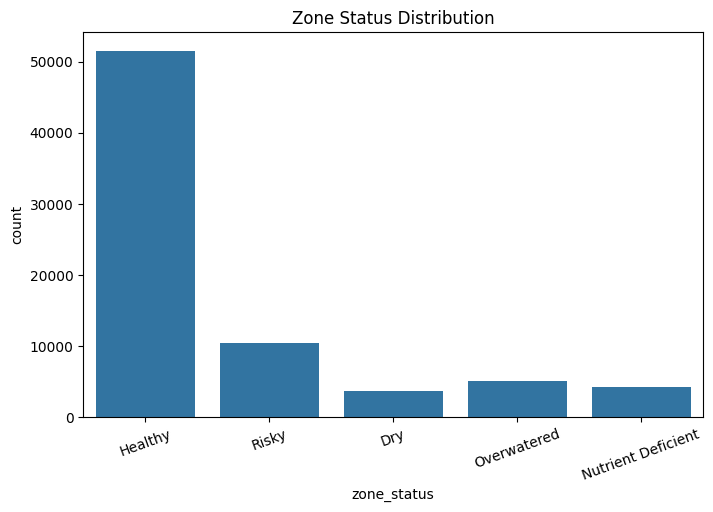

In [54]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='zone_status')
plt.title("Zone Status Distribution")
plt.xticks(rotation=20)
plt.show()

In [55]:
target_classification = 'zone_status'

drop_cols = [
    'zone_status',
    'zone_health_score',
    'recommendation',
    'zone_id',
    'field_id'
]

X = df.drop(columns=drop_cols)
y = df[target_classification]

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(exclude=['object']).columns.tolist()

print("Categorical Columns:", categorical_cols)
print("Numerical Columns:", numerical_cols[:10], "...")

Categorical Columns: ['zone_position', 'crop_type', 'crop_stage', 'soil_type', 'drainage_condition', 'mulching', 'weather_condition', 'irrigation_method', 'field_slope', 'waterlogging_risk']
Numerical Columns: ['zone_row', 'zone_col', 'crop_age_days', 'soil_moisture', 'soil_temperature_c', 'temperature_c', 'humidity_percent', 'rainfall_last_24h_mm', 'rain_probability_next_24h', 'wind_speed_kmph'] ...


In [56]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [57]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

In [58]:
zone_status_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=250,
        max_depth=18,
        min_samples_split=4,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
])

zone_status_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['zone_row', 'zone_col',
                                                   'crop_age_days',
                                                   'soil_moisture',
                                                   'soil_temperature_c',
                                                   'temperature_c',
                                                   'humidity_percent',
                                                   'rainfall_last_24h_mm',
                                                   'rain_probability_next_24h',
                                                   'wind_speed_kmph',
                                                   'sunlight_hours',
                                                   'evapotranspiration_mm_day',
                                                   'last_irrigation_days',
                                                   'crop_water_re...
                                                   'disease_risk_zone']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['zone_position', 'crop_type',
                                                   'crop_stage', 'soil_type',
                                                   'drainage_condition',
                                                   'mulching',
                                                   'weather_condition',
                                                   'irrigation_method',
                                                   'field_slope',
                                                   'waterlogging_risk'])])),
                ('classifier',
                 RandomForestClassifier(max_depth=18, min_samples_leaf=2,
                                        min_samples_split=4, n_estimators=250,
                                        n_jobs=-1, random_state=42))])

In [59]:
y_pred = zone_status_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9999333333333333

Classification Report:

                    precision    recall  f1-score   support

               Dry       1.00      1.00      1.00       740
           Healthy       1.00      1.00      1.00     10313
Nutrient Deficient       1.00      1.00      1.00       844
       Overwatered       1.00      1.00      1.00      1013
             Risky       1.00      1.00      1.00      2090

          accuracy                           1.00     15000
         macro avg       1.00      1.00      1.00     15000
      weighted avg       1.00      1.00      1.00     15000



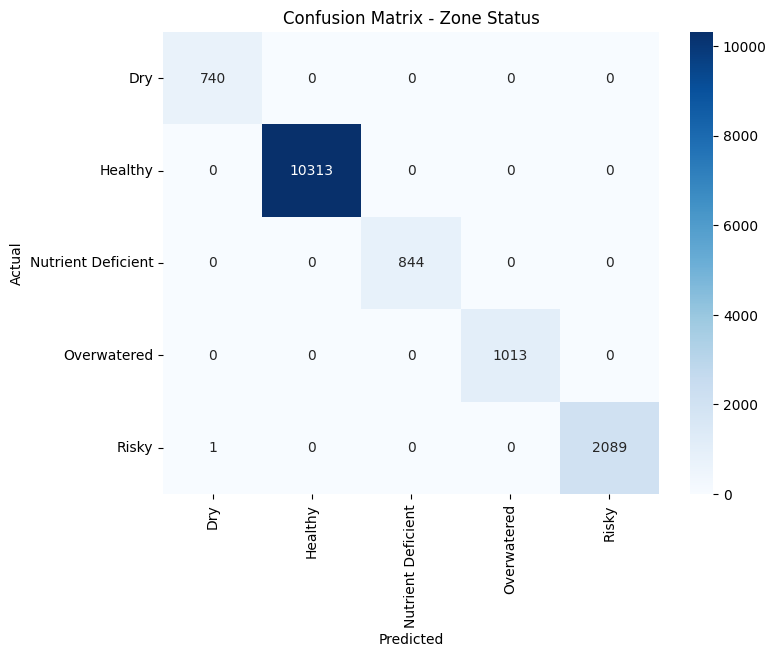

In [60]:
cm = confusion_matrix(y_test, y_pred, labels=zone_status_model.classes_)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=zone_status_model.classes_,
            yticklabels=zone_status_model.classes_)
plt.title("Confusion Matrix - Zone Status")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [61]:
target_regression = 'zone_health_score'

drop_cols_reg = [
    'zone_status',
    'zone_health_score',
    'recommendation',
    'zone_id',
    'field_id'
]

X_reg = df.drop(columns=drop_cols_reg)
y_reg = df[target_regression]

categorical_cols_reg = X_reg.select_dtypes(include=['object']).columns.tolist()
numerical_cols_reg = X_reg.select_dtypes(exclude=['object']).columns.tolist()

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

In [62]:
preprocessor_reg = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols_reg),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols_reg)
    ]
)

In [63]:
zone_health_model = Pipeline(steps=[
    ('preprocessor', preprocessor_reg),
    ('regressor', RandomForestRegressor(
        n_estimators=250,
        max_depth=18,
        min_samples_split=4,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
])

zone_health_model.fit(X_train_reg, y_train_reg)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['zone_row', 'zone_col',
                                                   'crop_age_days',
                                                   'soil_moisture',
                                                   'soil_temperature_c',
                                                   'temperature_c',
                                                   'humidity_percent',
                                                   'rainfall_last_24h_mm',
                                                   'rain_probability_next_24h',
                                                   'wind_speed_kmph',
                                                   'sunlight_hours',
                                                   'evapotranspiration_mm_day',
                                                   'last_irrigation_days',
                                                   'crop_water_re...
                                                   'disease_risk_zone']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['zone_position', 'crop_type',
                                                   'crop_stage', 'soil_type',
                                                   'drainage_condition',
                                                   'mulching',
                                                   'weather_condition',
                                                   'irrigation_method',
                                                   'field_slope',
                                                   'waterlogging_risk'])])),
                ('regressor',
                 RandomForestRegressor(max_depth=18, min_samples_leaf=2,
                                       min_samples_split=4, n_estimators=250,
                                       n_jobs=-1, random_state=42))])

In [64]:
y_pred_reg = zone_health_model.predict(X_test_reg)

print("MAE:", mean_absolute_error(y_test_reg, y_pred_reg))
print("R2 Score:", r2_score(y_test_reg, y_pred_reg))

MAE: 2.593180682837935
R2 Score: 0.9205432939609643


In [65]:
os.makedirs("models", exist_ok=True)

joblib.dump(zone_status_model, "models/zone_status_model.pkl")
joblib.dump(zone_health_model, "models/zone_health_score_model.pkl")
joblib.dump(X.columns.tolist(), "models/feature_columns.pkl")

print("✅ Models saved successfully!")

✅ Models saved successfully!


In [66]:
sample = X.sample(1, random_state=101)
sample

,zone_row,zone_col,zone_position,crop_type,crop_age_days,crop_stage,soil_type,soil_moisture,soil_temperature_c,drainage_condition,...,field_slope,ndvi_score,disease_risk_score,fertilizer_deficiency_score,irrigation_score,waterlogging_risk,waterlogging_score,irrigation_needed_zone,fertilizer_needed_zone,disease_risk_zone
15578,0,3,edge,chilli,139,maturity,red,52.22,33.64,good,...,low,0.47,0.289,0.537,0.34,low,0.01,0,0,0


In [67]:
pred_zone_status = zone_status_model.predict(sample)[0]
pred_health_score = zone_health_model.predict(sample)[0]

print("Predicted Zone Status:", pred_zone_status)
print("Predicted Health Score:", round(pred_health_score, 2))

Predicted Zone Status: Healthy
Predicted Health Score: 88.31


In [68]:
def get_recommendation_from_prediction(zone_status, health_score):
    if zone_status == 'Dry':
        return "💧 Irrigation required in this zone."
    elif zone_status == 'Healthy':
        return "✅ Zone is healthy. No immediate action needed."
    elif zone_status == 'Risky':
        return "⚠️ Check for disease, crop stress, and growth issues."
    elif zone_status == 'Overwatered':
        return "🚫 Avoid irrigation. Improve drainage immediately."
    elif zone_status == 'Nutrient Deficient':
        return "🌱 Apply fertilizer or nutrient support in this zone."
    else:
        return "📌 Monitor this zone regularly."

In [69]:
def predict_complete_field(field_df, status_model, health_model):
    prediction_df = field_df.copy()

    pred_status = status_model.predict(field_df)
    pred_health = health_model.predict(field_df)

    prediction_df['pred_zone_status'] = pred_status
    prediction_df['pred_zone_health_score'] = np.round(pred_health, 2)
    prediction_df['pred_recommendation'] = prediction_df.apply(
        lambda row: get_recommendation_from_prediction(
            row['pred_zone_status'], row['pred_zone_health_score']
        ),
        axis=1
    )

    return prediction_df

In [70]:
# Take one field (25 zones)
sample_field_full = df[df['field_id'] == 1].copy()

sample_field_input = sample_field_full.drop(columns=[
    'zone_status',
    'zone_health_score',
    'recommendation',
    'zone_id',
    'field_id'
])

predicted_field = predict_complete_field(sample_field_input, zone_status_model, zone_health_model)
predicted_field.head()

,zone_row,zone_col,zone_position,crop_type,crop_age_days,crop_stage,soil_type,soil_moisture,soil_temperature_c,drainage_condition,...,fertilizer_deficiency_score,irrigation_score,waterlogging_risk,waterlogging_score,irrigation_needed_zone,fertilizer_needed_zone,disease_risk_zone,pred_zone_status,pred_zone_health_score,pred_recommendation
0,0,0,corner,gram,36,vegetative,sandy,71.10,26.24,good,...,0.650,0.381,low,0.334,0,0,0,Healthy,83.37,✅ Zone is healthy. No immediate action needed.
1,0,1,edge,onion,75,flowering,silty,26.30,19.71,good,...,0.641,0.575,low,0.223,1,0,1,Risky,64.28,"⚠️ Check for disease, crop stress, and growth ..."
2,0,2,edge,brinjal,106,fruiting,silty,73.67,23.12,good,...,0.603,0.405,low,0.218,0,0,0,Healthy,81.93,✅ Zone is healthy. No immediate action needed.
3,0,3,edge,sunflower,122,maturity,clay,49.01,21.12,good,...,0.447,0.133,low,0.143,0,0,0,Healthy,93.05,✅ Zone is healthy. No immediate action needed.
4,0,4,corner,brinjal,74,flowering,clay,65.79,27.19,good,...,0.628,0.313,medium,0.539,1,0,1,Risky,63.32,"⚠️ Check for disease, crop stress, and growth ..."


In [71]:
status_to_num = {
    'Dry': 1,
    'Healthy': 2,
    'Risky': 3,
    'Overwatered': 4,
    'Nutrient Deficient': 5
}

In [72]:
# Merge back zone row/col for visualization
viz_df = sample_field_full[['zone_row', 'zone_col']].copy()
viz_df['pred_zone_status'] = predicted_field['pred_zone_status'].values
viz_df['pred_zone_health_score'] = predicted_field['pred_zone_health_score'].values
viz_df['status_num'] = viz_df['pred_zone_status'].map(status_to_num)

grid_matrix = viz_df.pivot(index='zone_row', columns='zone_col', values='status_num')
health_matrix = viz_df.pivot(index='zone_row', columns='zone_col', values='pred_zone_health_score')

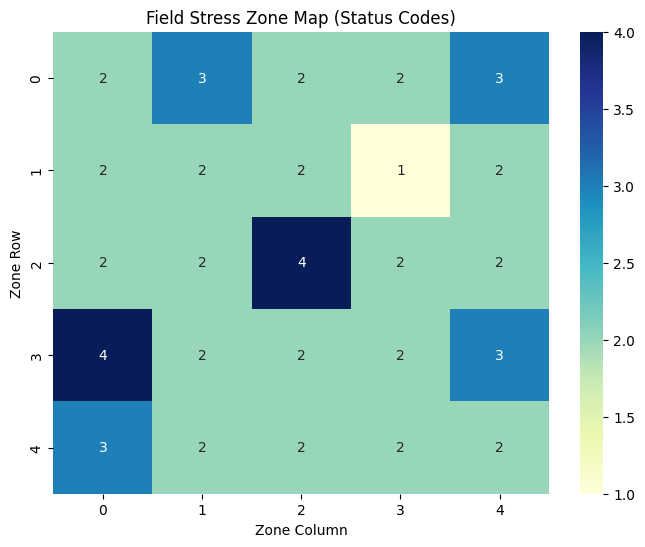

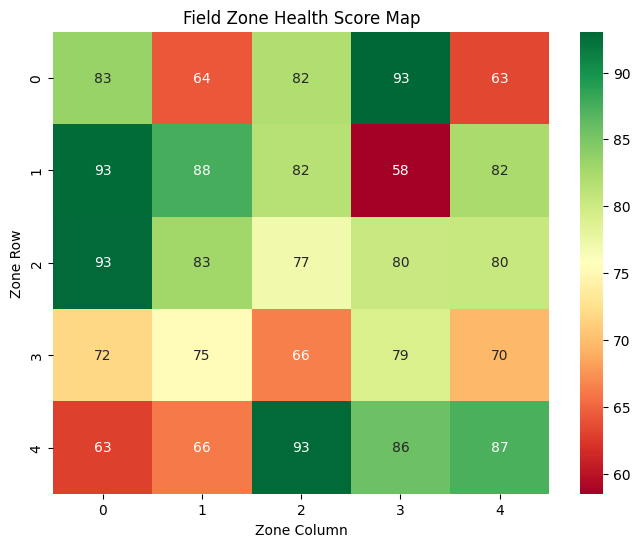

In [73]:
plt.figure(figsize=(8,6))
sns.heatmap(grid_matrix, annot=True, cmap='YlGnBu', cbar=True)
plt.title("Field Stress Zone Map (Status Codes)")
plt.xlabel("Zone Column")
plt.ylabel("Zone Row")
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(health_matrix, annot=True, cmap='RdYlGn', cbar=True)
plt.title("Field Zone Health Score Map")
plt.xlabel("Zone Column")
plt.ylabel("Zone Row")
plt.show()

In [74]:
legend = pd.DataFrame({
    'Code': [1, 2, 3, 4, 5],
    'Zone Status': ['Dry', 'Healthy', 'Risky', 'Overwatered', 'Nutrient Deficient']
})

legend

,Code,Zone Status
0,1,Dry
1,2,Healthy
2,3,Risky
3,4,Overwatered
4,5,Nutrient Deficient


In [75]:
summary = predicted_field['pred_zone_status'].value_counts().reset_index()
summary.columns = ['Zone Status', 'Count']
summary

,Zone Status,Count
0,Healthy,18
1,Risky,4
2,Overwatered,2
3,Dry,1


In [76]:
print("📍 FIELD SUMMARY REPORT")
print("-" * 40)

for status, count in predicted_field['pred_zone_status'].value_counts().items():
    print(f"{status}: {count} zones")

avg_health = predicted_field['pred_zone_health_score'].mean()
print(f"\nAverage Field Health Score: {avg_health:.2f}")

📍 FIELD SUMMARY REPORT
----------------------------------------
Healthy: 18 zones
Risky: 4 zones
Overwatered: 2 zones
Dry: 1 zones

Average Field Health Score: 78.37


In [77]:
final_export = sample_field_full[['field_id', 'zone_id', 'zone_row', 'zone_col']].copy()
final_export['pred_zone_status'] = predicted_field['pred_zone_status'].values
final_export['pred_zone_health_score'] = predicted_field['pred_zone_health_score'].values
final_export['pred_recommendation'] = predicted_field['pred_recommendation'].values

final_export.to_csv("data/sample_field_prediction_output.csv", index=False)
print("✅ Field prediction output saved!")

✅ Field prediction output saved!


In [78]:
# ============================
# SINGLE SAMPLE TEST
# ============================

sample_zone = pd.DataFrame([{
    'zone_row': 0,
    'zone_col': 0,
    'zone_position': 'corner',

    'crop_type': 'tomato',
    'crop_age_days': 58,
    'crop_stage': 'flowering',

    'soil_type': 'sandy',
    'soil_moisture': 16.5,
    'soil_temperature_c': 31.2,
    'drainage_condition': 'moderate',
    'mulching': 'no',

    'temperature_c': 36.8,
    'humidity_percent': 34.5,
    'rainfall_last_24h_mm': 0.5,
    'rain_probability_next_24h': 10,
    'wind_speed_kmph': 9.2,
    'sunlight_hours': 8.7,
    'evapotranspiration_mm_day': 6.2,
    'weather_condition': 'sunny',

    'last_irrigation_days': 5,
    'irrigation_method': 'flood',
    'crop_water_requirement_mm': 10.8,

    'fertilizer_level': 38.0,
    'field_slope': 'medium',

    'ndvi_score': 0.31,
    'disease_risk_score': 0.42,
    'fertilizer_deficiency_score': 0.74,
    'irrigation_score': 0.81,
    'waterlogging_risk': 'low',
    'waterlogging_score': 0.12,

    'irrigation_needed_zone': 1,
    'fertilizer_needed_zone': 1,
    'disease_risk_zone': 0
}])

sample_zone

,zone_row,zone_col,zone_position,crop_type,crop_age_days,crop_stage,soil_type,soil_moisture,soil_temperature_c,drainage_condition,...,field_slope,ndvi_score,disease_risk_score,fertilizer_deficiency_score,irrigation_score,waterlogging_risk,waterlogging_score,irrigation_needed_zone,fertilizer_needed_zone,disease_risk_zone
0,0,0,corner,tomato,58,flowering,sandy,16.5,31.2,moderate,...,medium,0.31,0.42,0.74,0.81,low,0.12,1,1,0


In [79]:
# ============================
# PREDICT SINGLE ZONE
# ============================

pred_zone_status = zone_status_model.predict(sample_zone)[0]
pred_health_score = zone_health_model.predict(sample_zone)[0]

print("🔍 Predicted Zone Status:", pred_zone_status)
print("📊 Predicted Health Score:", round(pred_health_score, 2))
print("💡 Recommendation:", get_recommendation_from_prediction(pred_zone_status, pred_health_score))

🔍 Predicted Zone Status: Nutrient Deficient
📊 Predicted Health Score: 60.51
💡 Recommendation: 🌱 Apply fertilizer or nutrient support in this zone.


In [81]:
# ============================
# HUMAN READABLE REPORT
# ============================

print("🌾 ZONE STRESS REPORT")
print("=" * 40)

print(f"Crop Type: {sample_zone.iloc[0]['crop_type']}")
print(f"Crop Stage: {sample_zone.iloc[0]['crop_stage']}")
print(f"Soil Type: {sample_zone.iloc[0]['soil_type']}")
print(f"Soil Moisture: {sample_zone.iloc[0]['soil_moisture']} %")
print(f"Temperature: {sample_zone.iloc[0]['temperature_c']} °C")
print(f"Humidity: {sample_zone.iloc[0]['humidity_percent']} %")
print(f"NDVI Score: {sample_zone.iloc[0]['ndvi_score']}")
print(f"Disease Risk Score: {sample_zone.iloc[0]['disease_risk_score']}")
print(f"Fertilizer Deficiency Score: {sample_zone.iloc[0]['fertilizer_deficiency_score']}")
print(f"Irrigation Score: {sample_zone.iloc[0]['irrigation_score']}")

print("\n🔍 MODEL OUTPUT")
print("-" * 40)
print(f"Predicted Zone Status: {pred_zone_status}")
print(f"Predicted Health Score: {round(pred_health_score, 2)}")
print(f"Recommendation: {get_recommendation_from_prediction(pred_zone_status, pred_health_score)}")

🌾 ZONE STRESS REPORT
Crop Type: tomato
Crop Stage: flowering
Soil Type: sandy
Soil Moisture: 16.5 %
Temperature: 36.8 °C
Humidity: 34.5 %
NDVI Score: 0.31
Disease Risk Score: 0.42
Fertilizer Deficiency Score: 0.74
Irrigation Score: 0.81

🔍 MODEL OUTPUT
----------------------------------------
Predicted Zone Status: Nutrient Deficient
Predicted Health Score: 60.51
Recommendation: 🌱 Apply fertilizer or nutrient support in this zone.
